In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
import numpy as np
import geopandas as gpd
import pandas as pd
import glob
import os
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import normaltest, probplot, skew, kurtosis

Summarize P1 layers

In [115]:
# Folder containing the CSV files
data_dir = '/content/drive/MyDrive/CCRI/CCRR_repo/data'

#!cp -r /content/drive/MyDrive/p1_exposure/* /content/drive/MyDrive/CCRI/CCRR_repo/data/p1_exposure/
!find /content/drive/MyDrive/p1_exposure/ -type f \
  ! -name '*ge*' \
  ! -name '*topic*' \
  -exec cp {} /content/drive/MyDrive/CCRI/CCRR_repo/data/pillar1_data/ \;



In [145]:
adm0_df = gpd.read_file('/content/drive/MyDrive/CCRI/boundary/final_georepo/adm0.geojson')

In [146]:
adm0_df.columns

Index(['ucode', 'uuid', 'concept_uuid', 'is_latest', 'start_date', 'end_date',
       'name', 'level', 'level_name', 'type', 'PCode', 'ISO3', 'UcodeIn',
       'WFP_ID', 'MapClr', 'UcodeID', 'default', 'name_en', 'Map label',
       'Alt name', 'Alternative name', 'geometry'],
      dtype='object')

In [147]:
adm0_df = adm0_df[['ISO3','ucode','type', 'name']]

In [148]:
if not adm0_df.empty:
    merged_exposure_df = adm0_df[['ISO3', 'name', 'ucode']].copy()
    merged_exposure_df = merged_exposure_df.rename(columns={
        'ISO3': 'iso3',
        'name': 'adm0_name'
    })

In [149]:
merged_exposure_df

,iso3,adm0_name,ucode
0,RWA,Rwanda,RWA_V1
1,ASM,American Samoa (USA),ASM_V1
2,AGO,Angola,AGO_V1
3,ATA,Antarctica,ATA_V1
4,BLZ,Belize,BLZ_V1
...,...,...,...
284,STP,Sao Tome and Principe,STP_V2
285,HTI,Haiti,HTI_V2
286,NRU,Nauru,NRU_V2
287,TCA,Turks and Caicos Islands,TCA_V2


In [150]:
iso3_name = 'iso3'
ucode_name = 'ucode'
adm_name = 'adm0_name'

In [151]:
path = f'{data_dir}/pillar1_data'
all_files = glob.glob(path + "/*.csv")

for file in all_files:
    df = pd.read_csv(file, index_col=None, header=0)
    df = df.merge(merged_exposure_df, left_on='ucode', right_on='ucode')
    #df =  df[(df['type'] == 'State')] #now we are running this for the entire globe
    filename_only = file.split('/')[-1]
    first_two_words = '_'.join(filename_only.split('_')[:2])
    print(f"{first_two_words}: {df['child_population_exposed'].sum()}")

river_flood: 351551982.7623372
coastal_flood: 35827320.33709195
tropical_storm: 669537962.0903559
agricultural_drought: 1359736487.0220785
drought_spei: 1050672262.4009507
drought_spi: 988192379.1350923
heatwave_frequency: 1052414726.1001548
heatwave_duration: 1091139761.495072
heatwave_severity: 272992358.1110057
extreme_heat: 1184841948.1491132
fire_FRP: 88068634.34124212
fire_frequency: 141791319.48251933
sand_dust: 130643115.12051202
air_pollution: 2317498930.1891413
vectorborne_malariapv: 545899708.9716974
vectorborne_malariapf: 1003468553.5843368


Hazard data normalization test with plots

In [152]:
#define function to remove outliers and find min max values to reduce skew
def trim_outliers_iteratively(values, max_skew=2, max_kurtosis=3.5):
    """
    Iteratively removes extreme min/max values until skewness <= 2 and kurtosis <= 3.5.
    Returns the trimmed dataset along with the final min and max.
    """
    # values = values.dropna().values  # Ensure no NaNs
    # values = np.log1p(values)
    while True:
        current_skew = skew(values)
        current_kurtosis = kurtosis(values)

        if abs(current_skew) <= max_skew and current_kurtosis <= max_kurtosis:
            break  # Stop if conditions are met

        # Remove min and max values
        min_val, max_val = values.min(), values.max()
        values = values[(values > min_val) & (values < max_val)]  # Trim extreme min/max

    return values, values.min(), values.max()

In [153]:
def boxplot_outlier_detection(values):
    """
    Detect outliers using the IQR method (1.5 IQR rule).
    """
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    # Calculate IQR (Interquartile Range)
    IQR = Q3 - Q1
    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Return values that are within bounds
    return values[(values >= lower_bound) & (values <= upper_bound)], lower_bound, upper_bound

ploting normalized absolute exposure

processed : river_flood min: 2.1342600225959676 max: 7.8236422084772395
river_flood: Log Transformation and Scaling - skew=-0.208, kurtosis=0.409
IQR processed : river_flood min: 2.362706844573963 max: 7.853890827332299


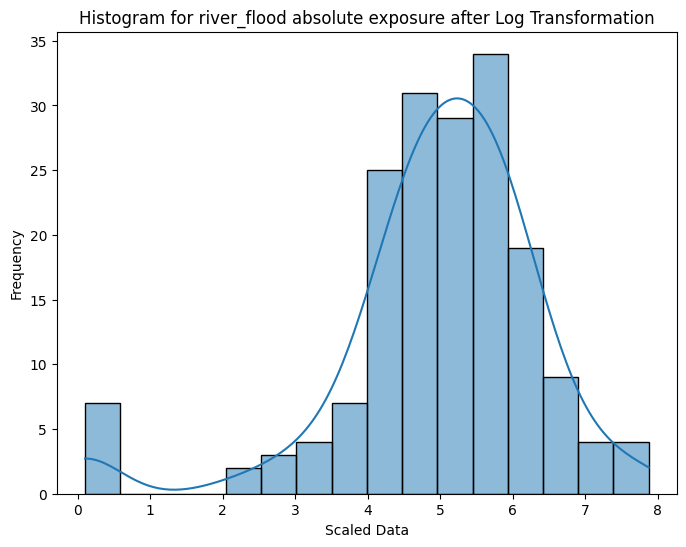

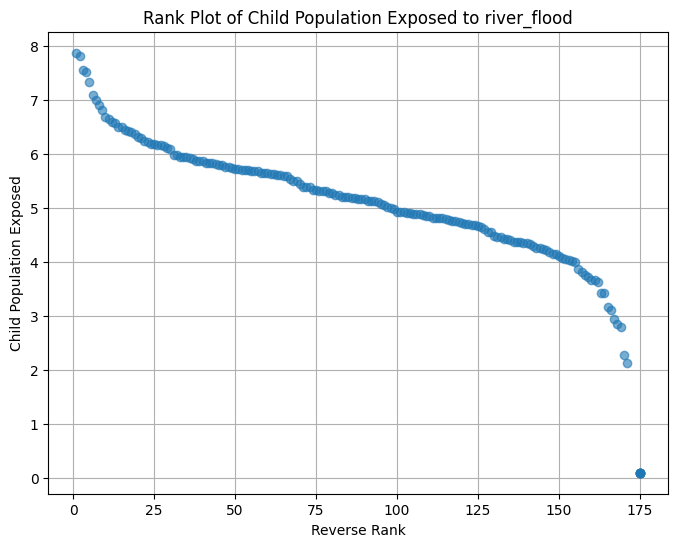

processed : coastal_flood min: 0.1 max: 7.163006569250576
coastal_flood: Log Transformation and Scaling - skew=0.289, kurtosis=-1.367
IQR processed : coastal_flood min: -5.561475574000408 max: 9.535792623334013


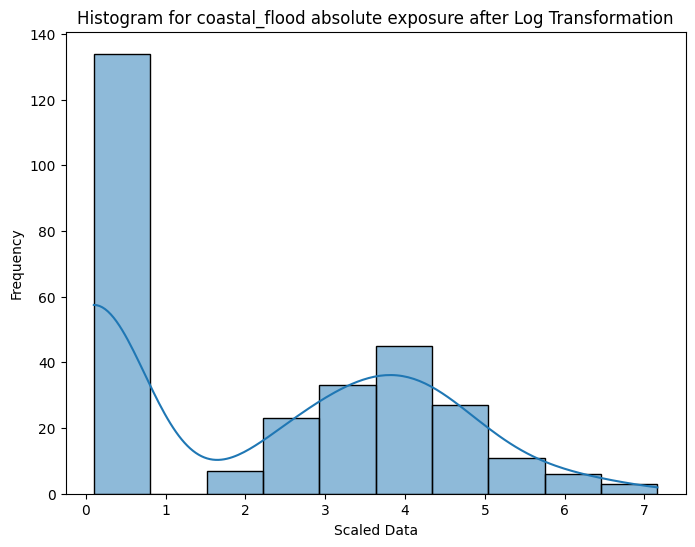

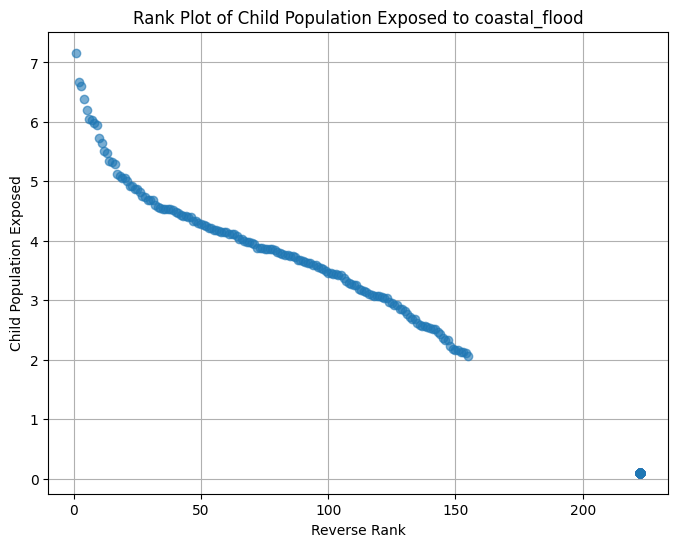

processed : tropical_storm min: 0.1 max: 8.194577209993167
tropical_storm: Log Transformation and Scaling - skew=0.138, kurtosis=-1.580
IQR processed : tropical_storm min: -8.011891418588577 max: 13.619819030980961


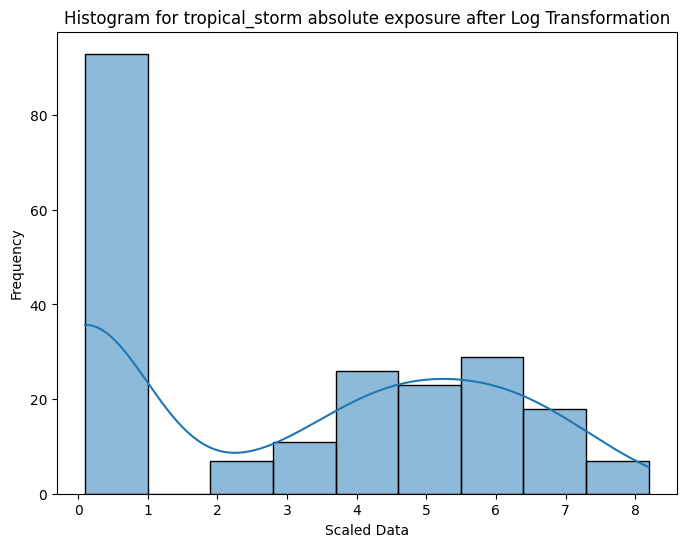

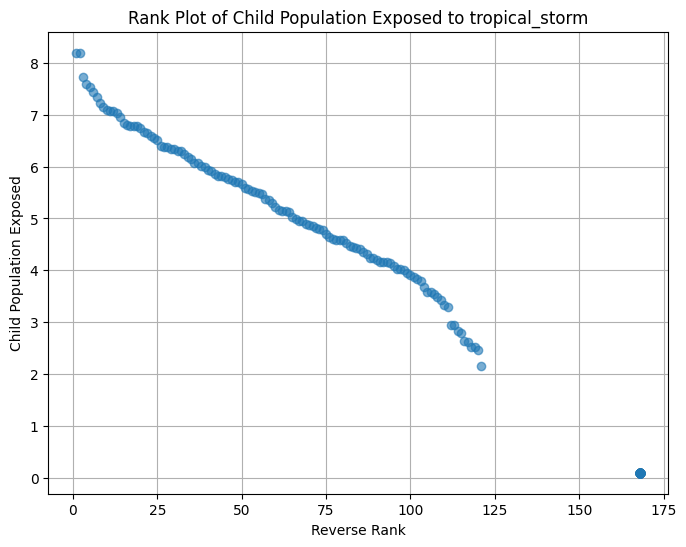

processed : agricultural_drought min: 0.1 max: 8.570492149357596
agricultural_drought: Log Transformation and Scaling - skew=-1.475, kurtosis=1.967
IQR processed : agricultural_drought min: 2.012036345131302 max: 9.343145870123598


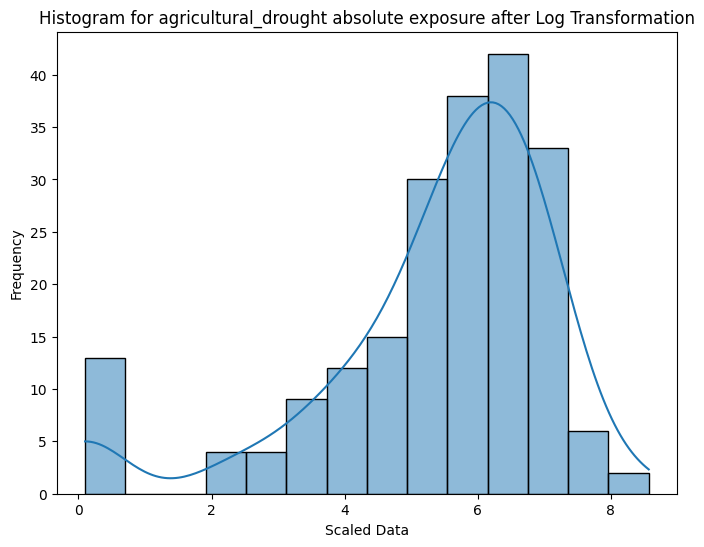

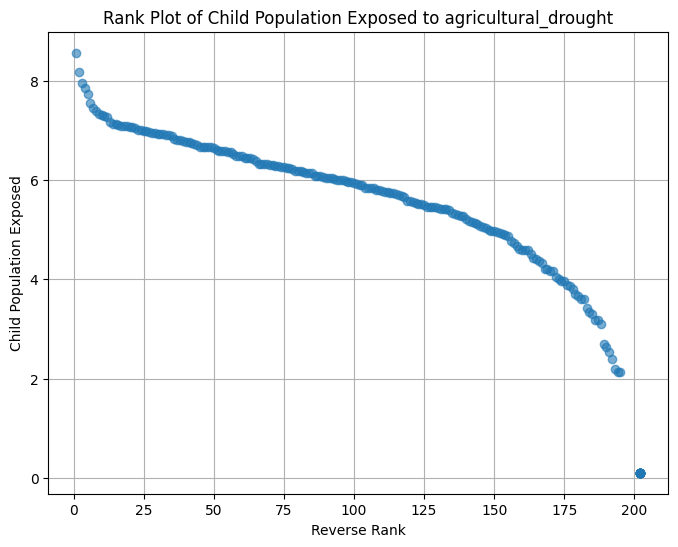

processed : drought_spei min: 0.1 max: 8.431002403640727
drought_spei: Log Transformation and Scaling - skew=-0.670, kurtosis=-0.990
IQR processed : drought_spei min: -2.603853918383171 max: 11.609554790270614


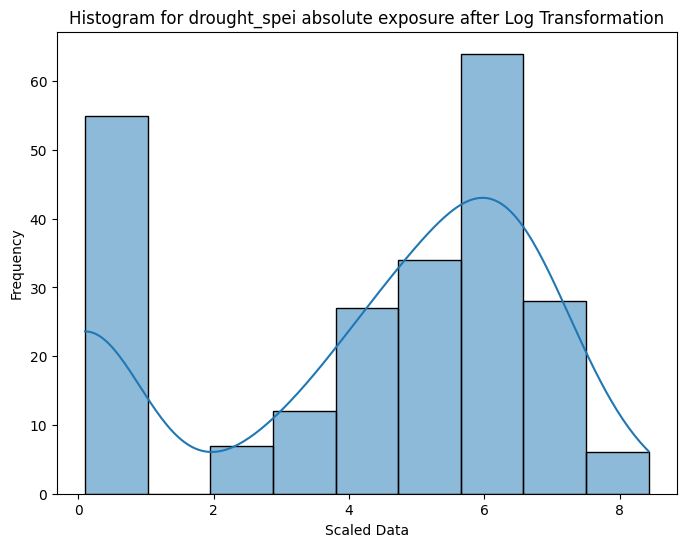

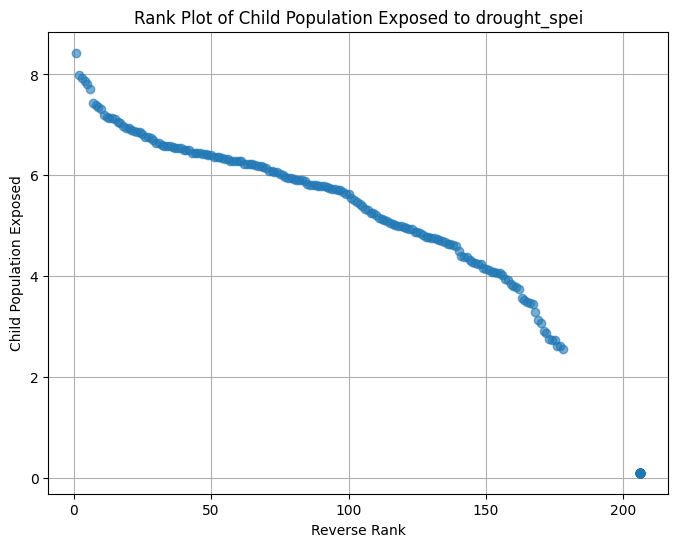

processed : drought_spi min: 0.1 max: 8.180697335569068
drought_spi: Log Transformation and Scaling - skew=-0.691, kurtosis=-1.136
IQR processed : drought_spi min: -9.273307640385056 max: 15.72217940064176


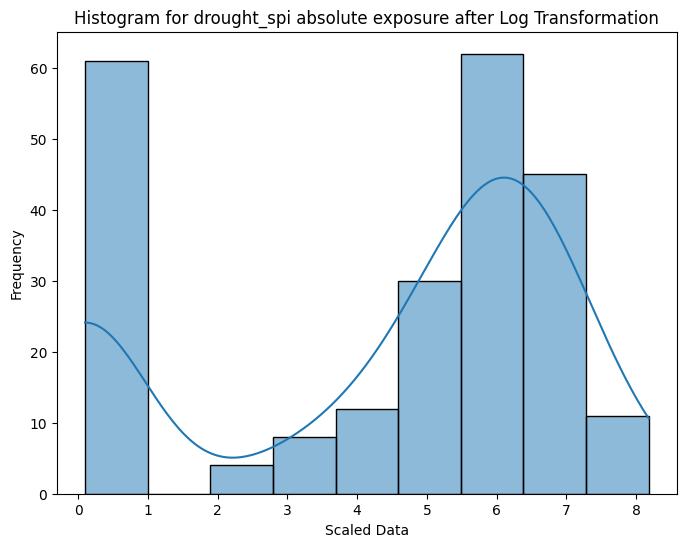

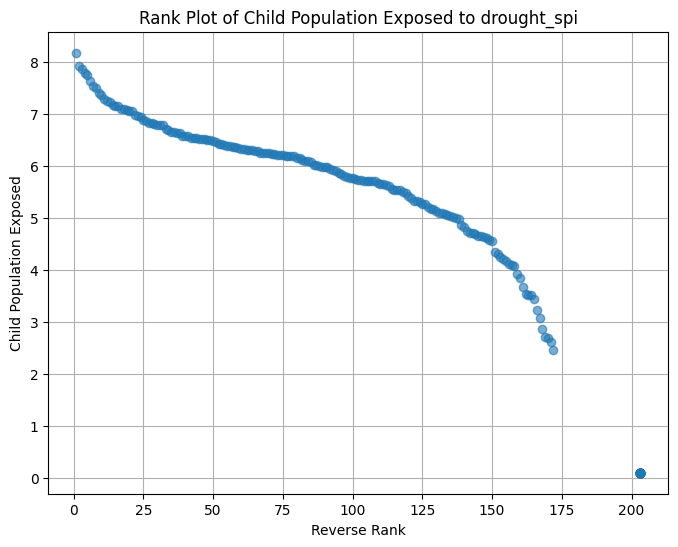

processed : heatwave_frequency min: 0.1 max: 7.855879625198364
heatwave_frequency: Log Transformation and Scaling - skew=-0.963, kurtosis=-0.323
IQR processed : heatwave_frequency min: -0.3869677820717081 max: 10.445809988795256


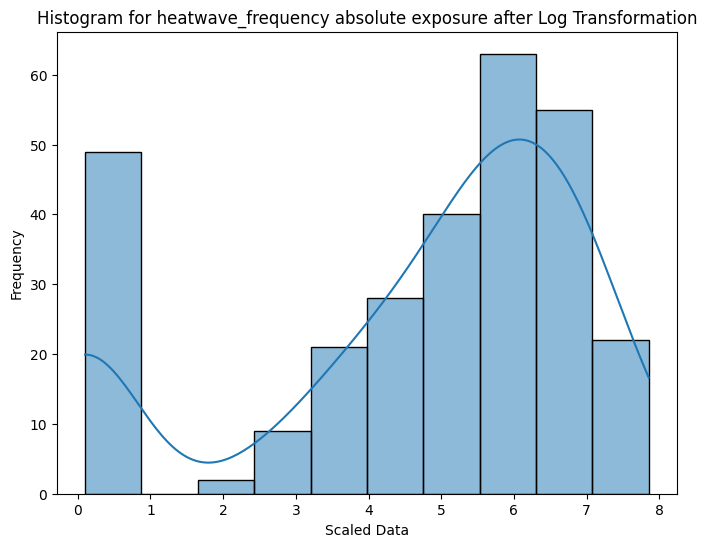

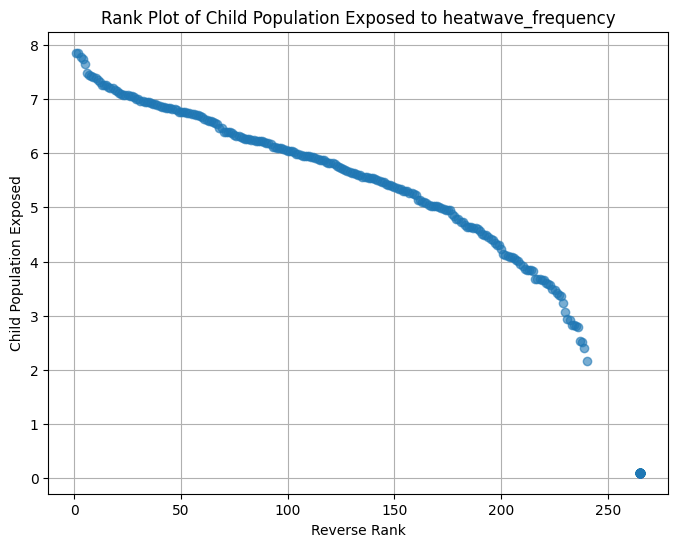

processed : heatwave_duration min: 0.1 max: 7.959861237421545
heatwave_duration: Log Transformation and Scaling - skew=-0.301, kurtosis=-1.577
IQR processed : heatwave_duration min: -9.199557124469434 max: 15.599261874115722


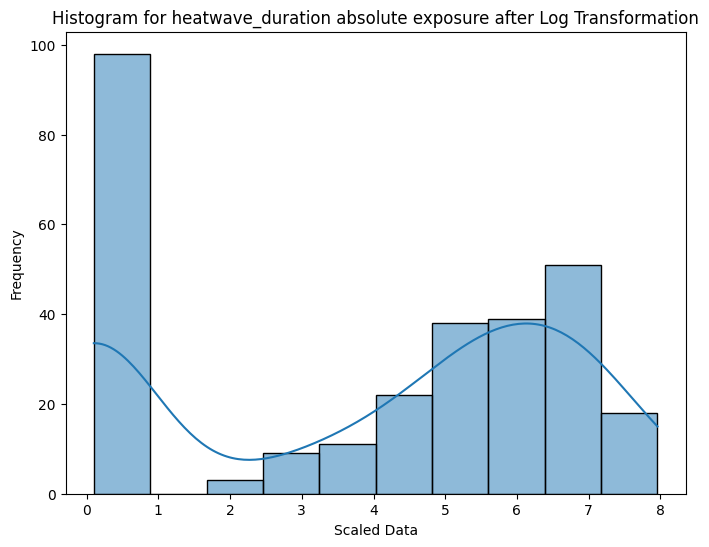

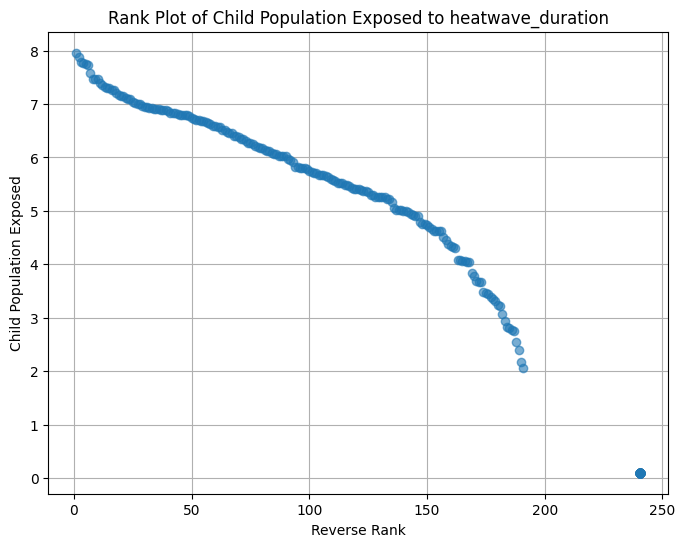

processed : heatwave_severity min: 0.1 max: 7.879100272703294
heatwave_severity: Log Transformation and Scaling - skew=0.585, kurtosis=-1.410
IQR processed : heatwave_severity min: -7.157347733999437 max: 12.195579556665727


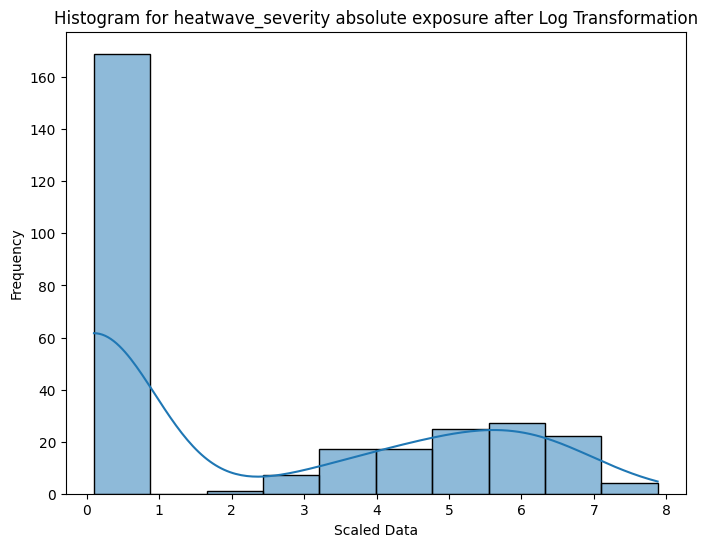

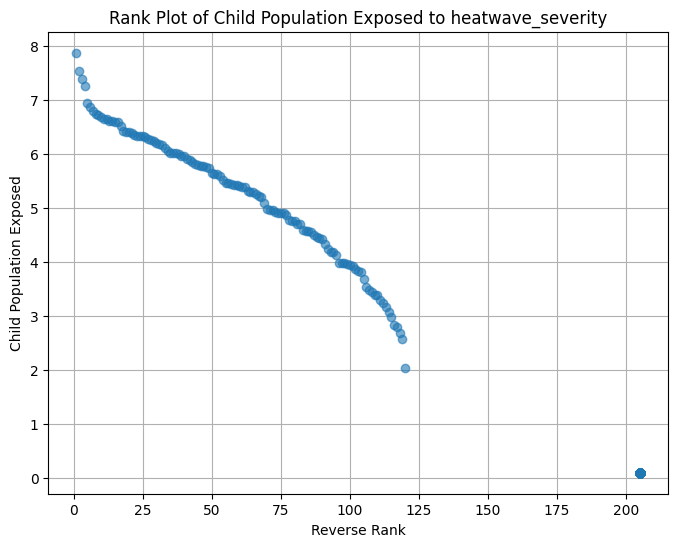

processed : extreme_heat min: 0.1 max: 8.598808536509011
extreme_heat: Log Transformation and Scaling - skew=0.260, kurtosis=-1.760
IQR processed : extreme_heat min: -9.07412650711361 max: 15.390210845189348


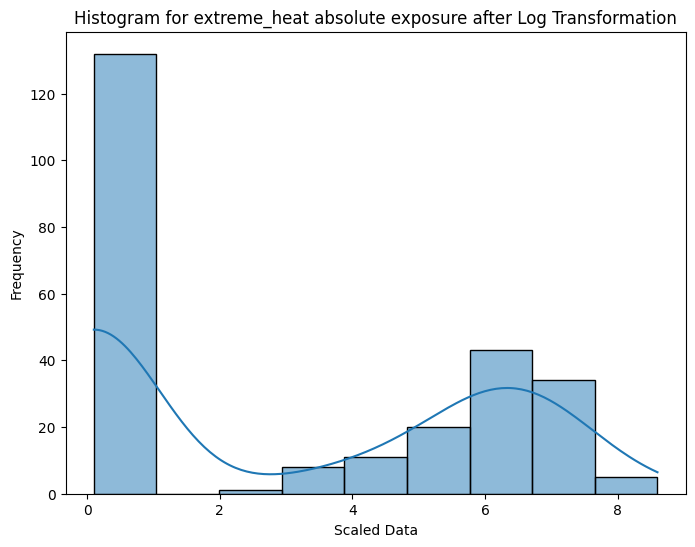

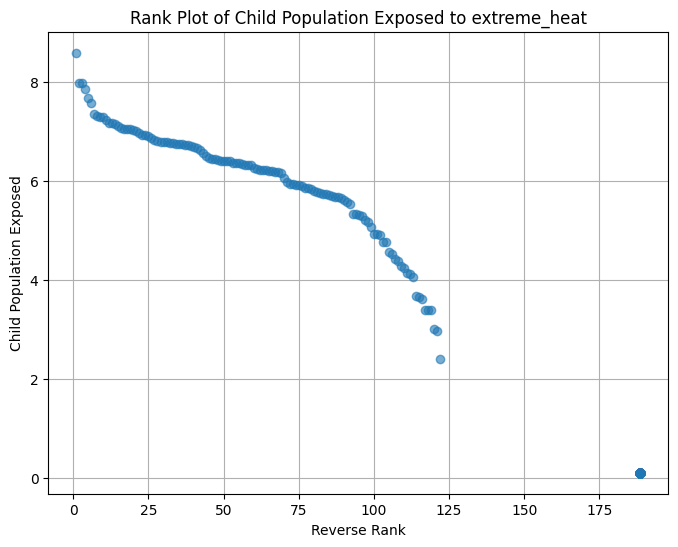

processed : fire_FRP min: 0.1 max: 6.8775353280138445
fire_FRP: Log Transformation and Scaling - skew=-0.725, kurtosis=-0.982
IQR processed : fire_FRP min: -2.433993667836687 max: 10.150409390950042


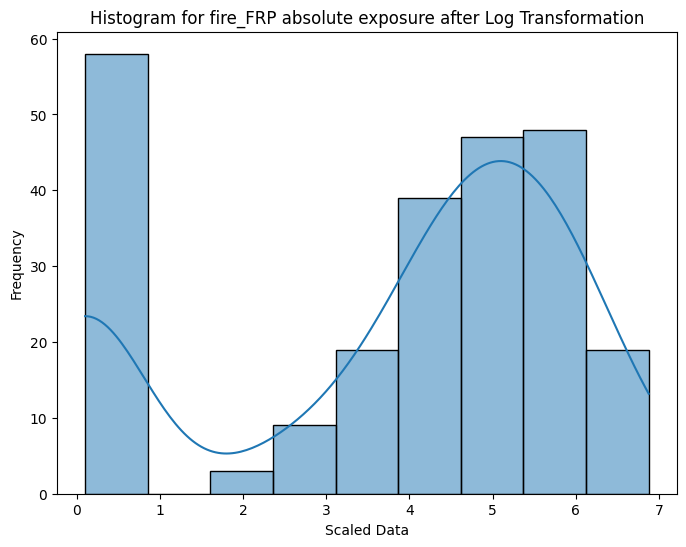

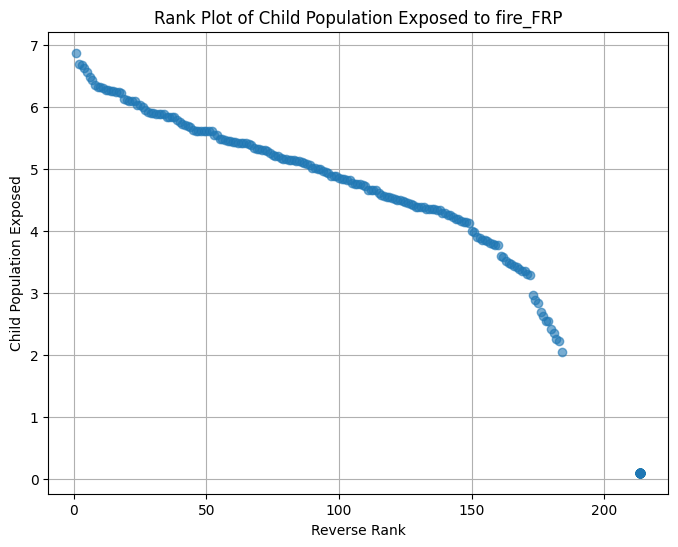

processed : fire_frequency min: 0.1 max: 7.350277231180149
fire_frequency: Log Transformation and Scaling - skew=-0.441, kurtosis=-1.236
IQR processed : fire_frequency min: -7.772249364636441 max: 13.2204156077274


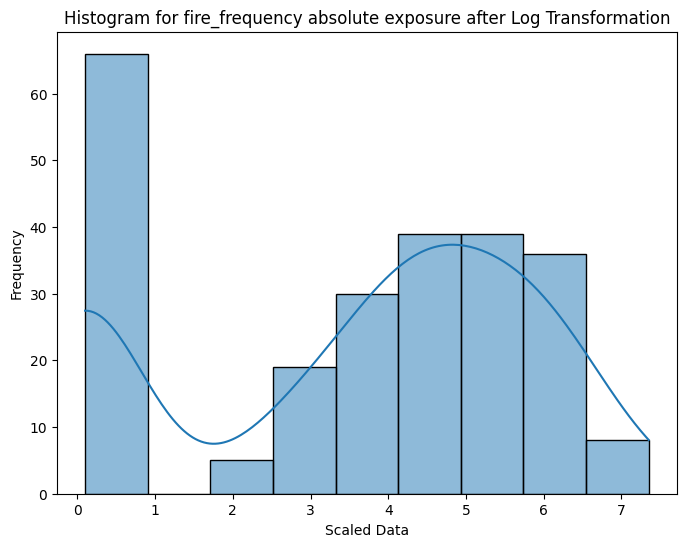

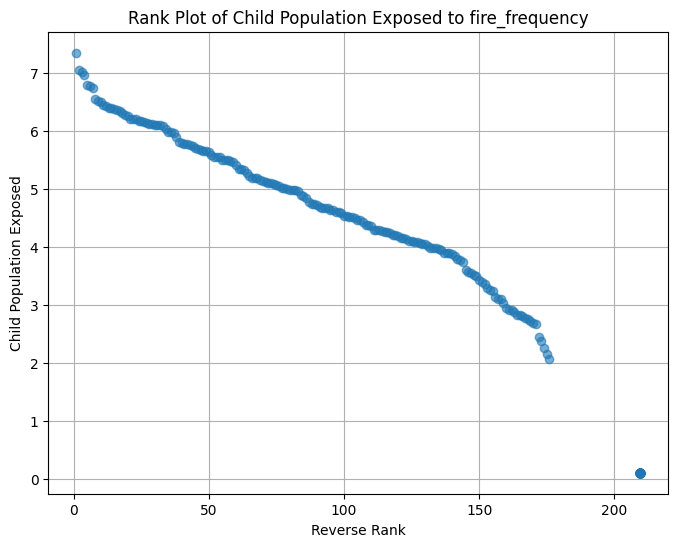

processed : sand_dust min: 0.1 max: 7.205487919815677
sand_dust: Log Transformation and Scaling - skew=0.278, kurtosis=-1.377
IQR processed : sand_dust min: -6.599194438158075 max: 11.26532406359679


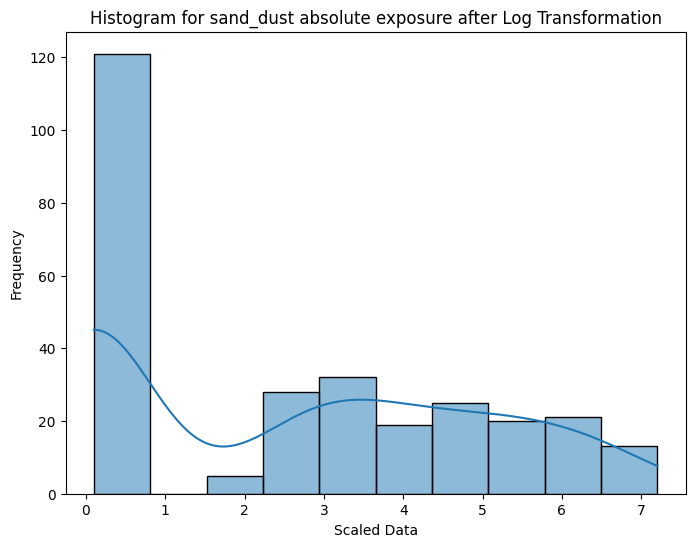

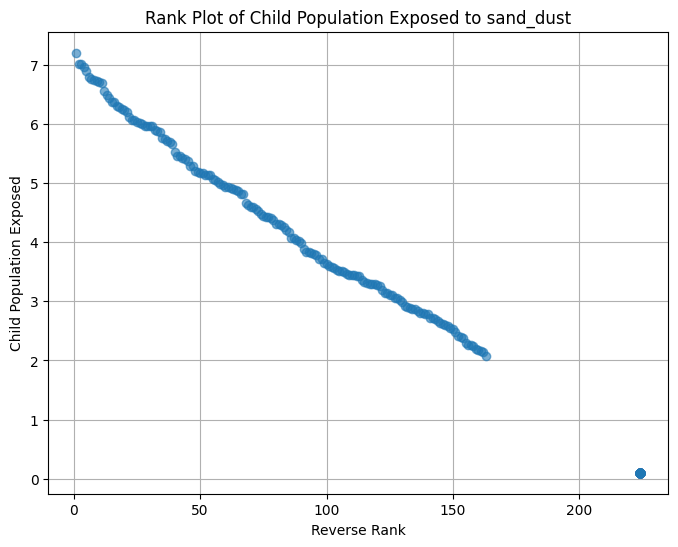

processed : air_pollution min: 0.1 max: 8.628127748006003
air_pollution: Log Transformation and Scaling - skew=-1.130, kurtosis=0.242
IQR processed : air_pollution min: -0.08172744517651864 max: 10.933571011554797


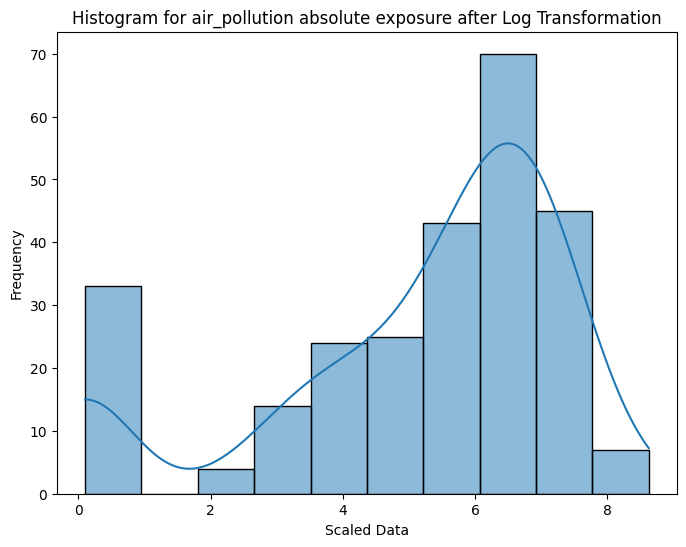

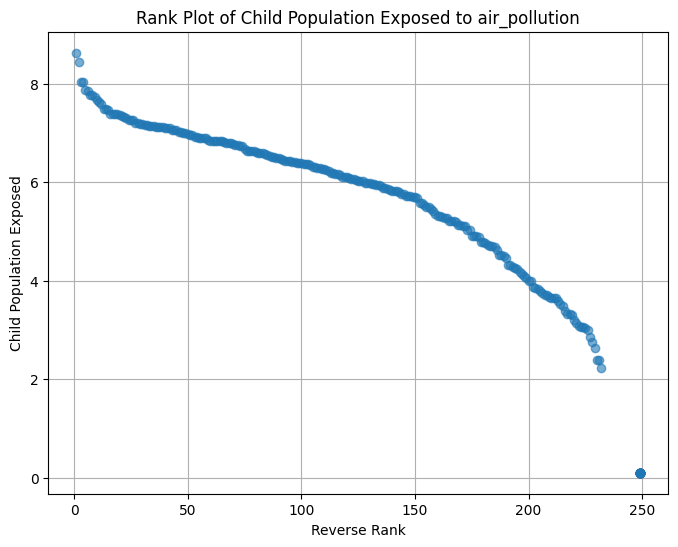

processed : vectorborne_malariapv min: 0.1 max: 8.470720892253809
vectorborne_malariapv: Log Transformation and Scaling - skew=0.004, kurtosis=-1.571
IQR processed : vectorborne_malariapv min: -8.61079471135129 max: 14.617991185585481


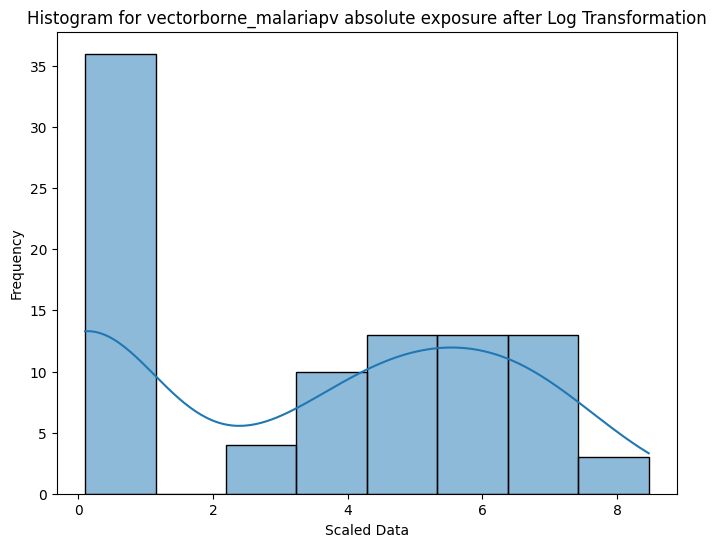

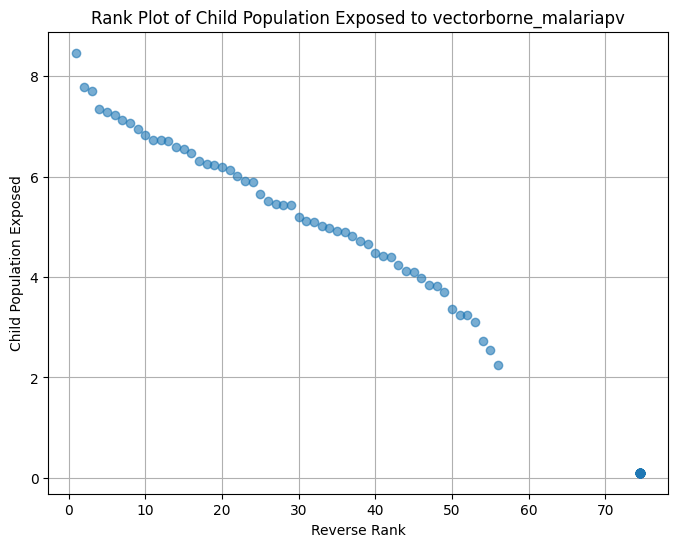

processed : vectorborne_malariapf min: 0.1 max: 8.456219870928646
vectorborne_malariapf: Log Transformation and Scaling - skew=-0.448, kurtosis=-1.451
IQR processed : vectorborne_malariapf min: -9.826790118036762 max: 16.644650196727934


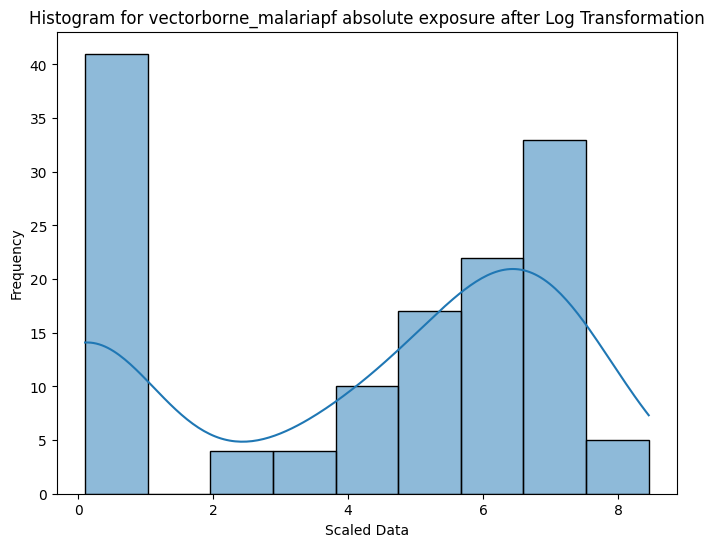

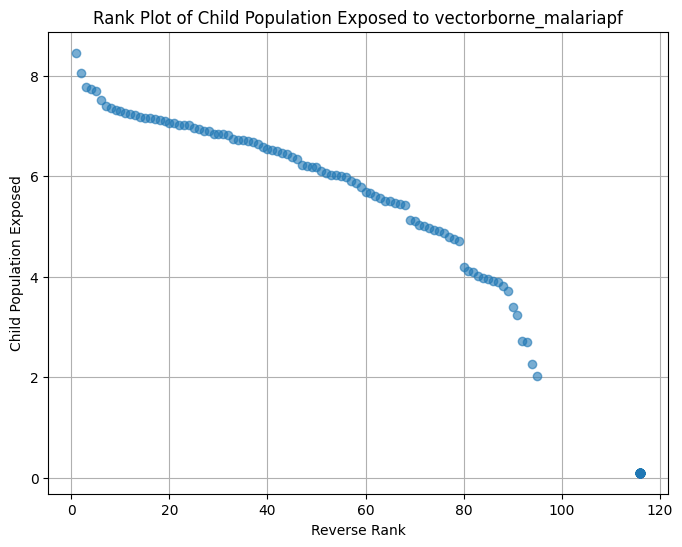

In [154]:

# Folder containing the CSV files
path = f'{data_dir}/pillar1_data'
all_files = glob.glob(path + "/*.csv")

for file in all_files:
    # Exclude the specified file
    df = pd.read_csv(file, index_col=None, header=0)
    df = df.rename(columns={'exposed': 'child_population_exposed'})
    filename_only = file.split('/')[-1]
    hazard_name = '_'.join(filename_only.split('_')[:2])

    if ucode_name not in df.columns or 'child_population_exposed' not in df.columns:
        continue  # Skip files missing required columns

    df = df[[ucode_name, iso3_name, 'child_population_exposed']].dropna()

    # Apply iterative trimming
    # before data trimming, log10 is applied to values higher than 100 otherwise asign 0.1
    df['child_population_exposed'] = df['child_population_exposed'].dropna().values  # Ensure no NaNs
    with np.errstate(divide='ignore'):
      df['child_population_exposed'] = np.where(
          df['child_population_exposed'] > 100,
          np.log10(df['child_population_exposed']),
          0.1
      )
    trimmed_values, min_trimmed, max_trimmed = trim_outliers_iteratively(df['child_population_exposed'])
    iqr_trimmed_values, iqr_lower_bound, iqr_upper_bound = boxplot_outlier_detection(df['child_population_exposed'])

    print(f"processed : {hazard_name} min: {min_trimmed} max: {max_trimmed}" )
    current_skew = skew(trimmed_values)
    current_kurtosis = kurtosis(trimmed_values)
    print(f"{hazard_name}: Log Transformation and Scaling - skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")
    print(f"IQR processed : {hazard_name} min: {iqr_lower_bound} max: {iqr_upper_bound}" )

    # Plot histogram and normality check
    plt.figure(figsize=(8, 6))
    sns.histplot(df['child_population_exposed'], kde=True)
    plt.title(f"Histogram for {hazard_name} absolute exposure after Log Transformation")
    plt.xlabel("Scaled Data")
    plt.ylabel("Frequency")
    plt.show()

    # Compute ranks in reverse order
    df['rank_reverse'] = df['child_population_exposed'].rank(method='average', ascending=False)
    plt.figure(figsize=(8, 6))
    plt.plot(df['rank_reverse'], df['child_population_exposed'], marker='o', linestyle='', alpha=0.6)
    plt.xlabel("Reverse Rank")
    plt.ylabel("Child Population Exposed")
    plt.title(f"Rank Plot of Child Population Exposed to {hazard_name}")
    plt.grid(True)
    plt.show()



0.0
75.94668833308752
Processed: river_flood | Min: 0.26379314041897145 | Max: 33.96712660402101
river_flood: Log Transformation - skew=1.821, kurtosis=3.468
IQR processed : river_flood min: -868901.248860168 max: 1518621.262102433


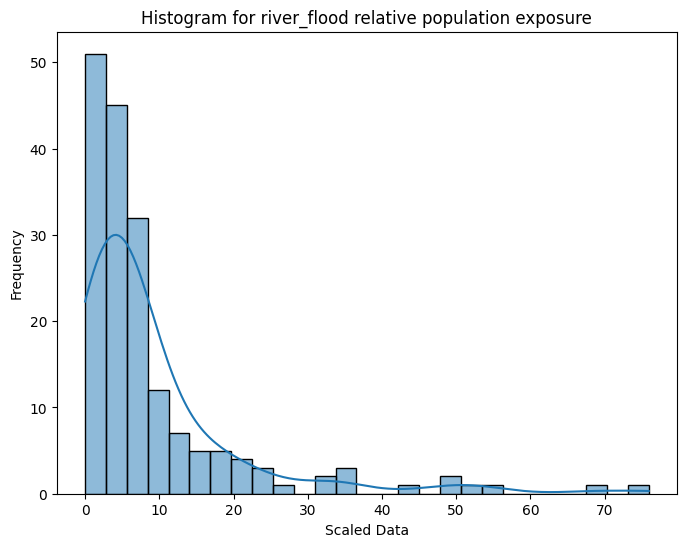

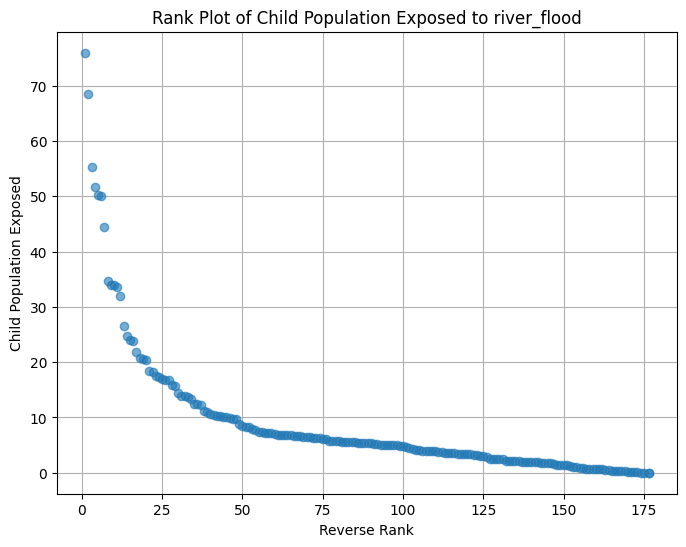

0.0
67.24776739418826
Processed: coastal_flood | Min: 0.013328280331921048 | Max: 7.33332134166792
coastal_flood: Log Transformation - skew=1.964, kurtosis=2.748
IQR processed : coastal_flood min: -11230.73832606481 max: 18717.897210108014


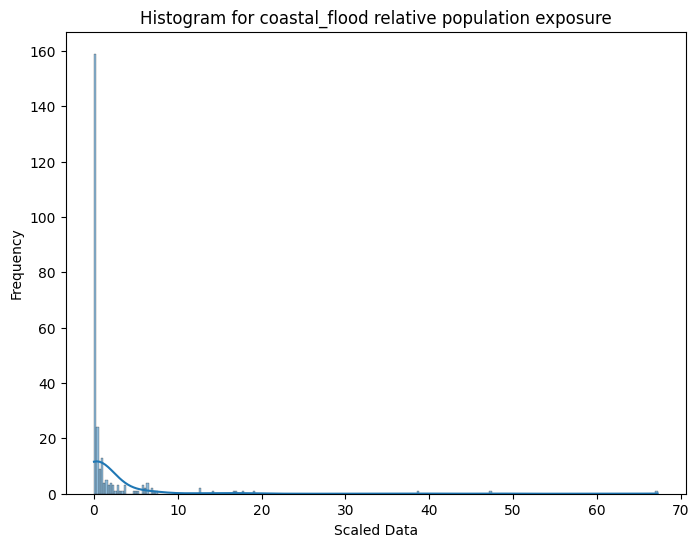

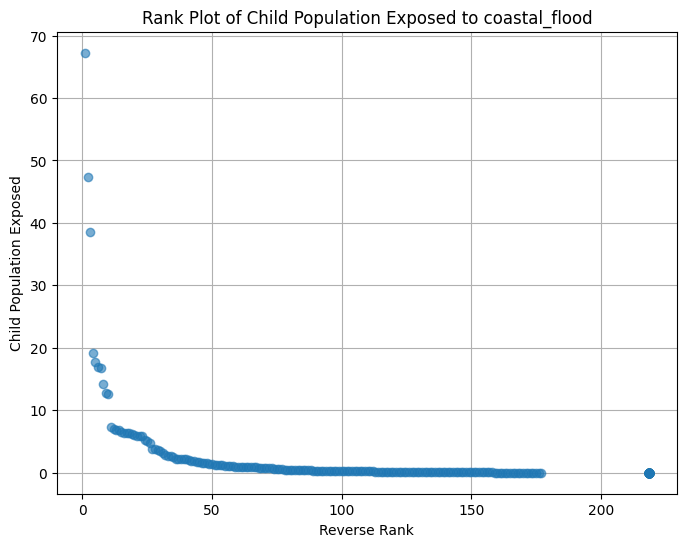

0.0
100.00000000000003
Processed: tropical_storm | Min: 1.5916521002476738e-05 | Max: 100.0
tropical_storm: Log Transformation - skew=-1.186, kurtosis=-0.286
IQR processed : tropical_storm min: -483183.6324268764 max: 805306.0540447941


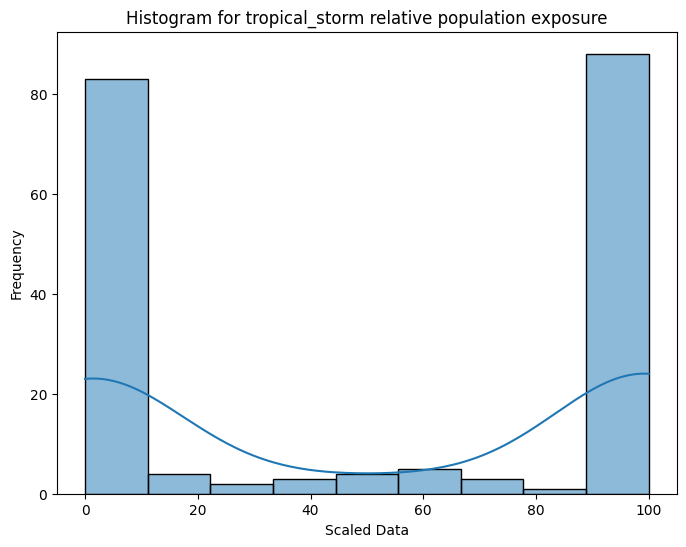

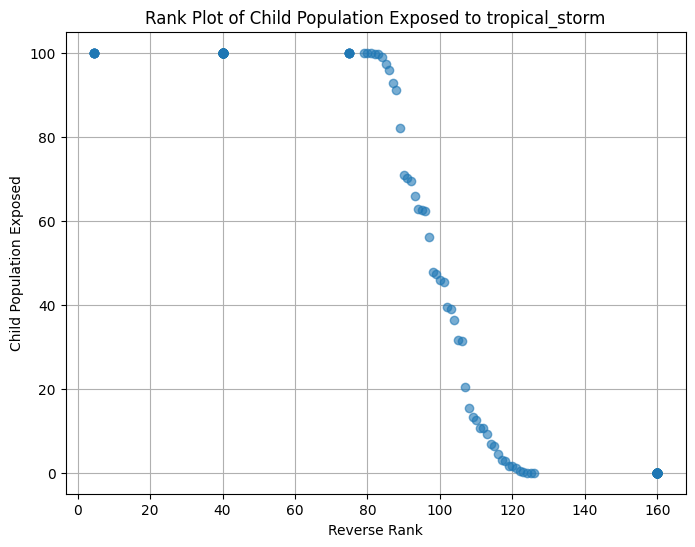

0.0
100.0
Processed: agricultural_drought | Min: 0.0004961213147821053 | Max: 94.95454183835396
agricultural_drought: Log Transformation - skew=0.082, kurtosis=-1.162
IQR processed : agricultural_drought min: -5745102.935183689 max: 9729106.245505625


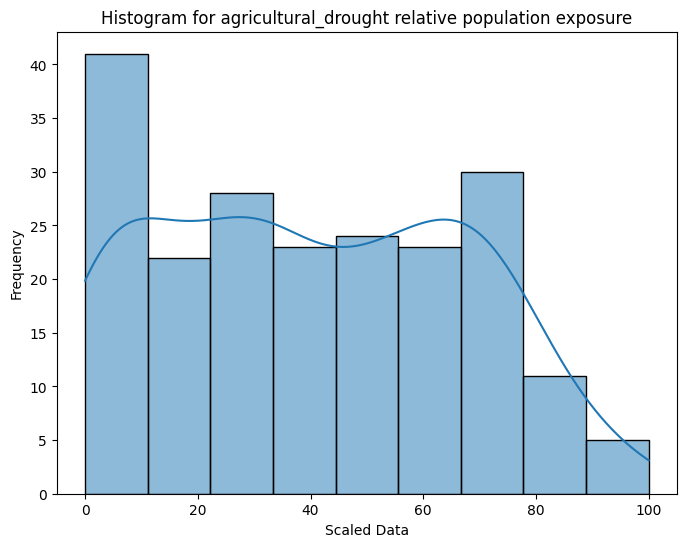

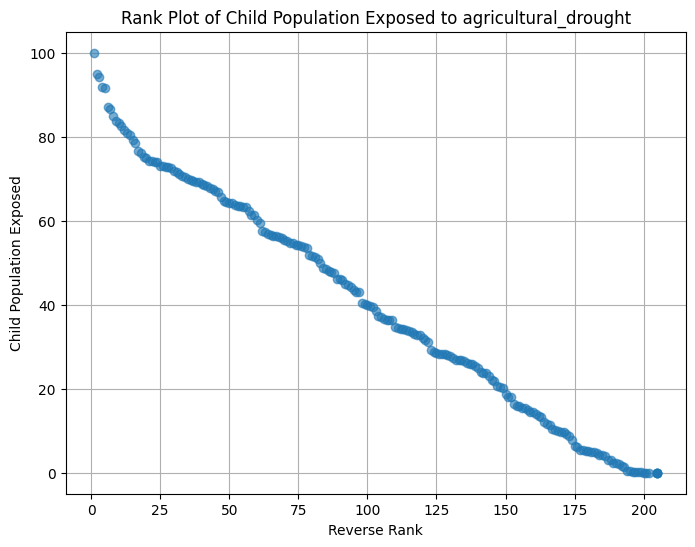

0.0
100.0
Processed: drought_spei | Min: 0.0074878219209646895 | Max: 99.99998938964606
drought_spei: Log Transformation - skew=0.723, kurtosis=-0.990
IQR processed : drought_spei min: -2853745.919992633 max: 4757662.725099236


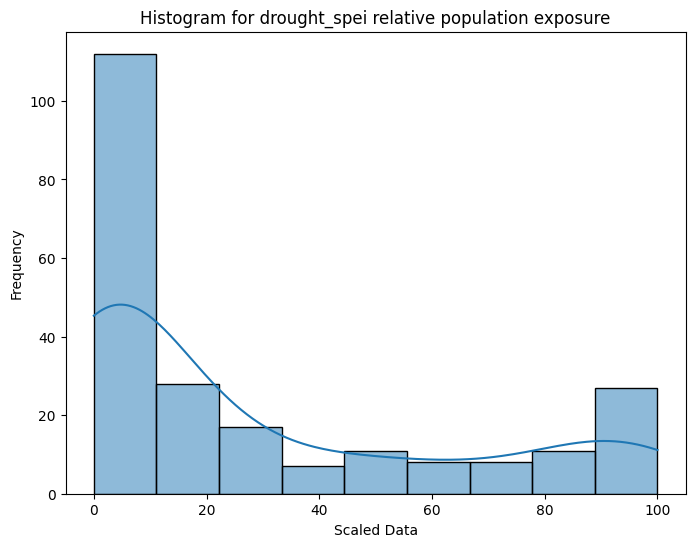

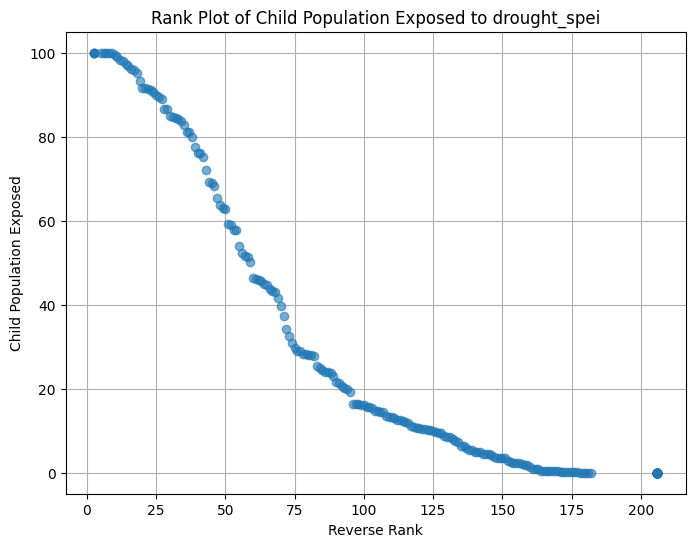

0.0
100.00000000000003
Processed: drought_spi | Min: 0.0112694081751698 | Max: 100.0
drought_spi: Log Transformation - skew=0.154, kurtosis=-1.573
IQR processed : drought_spi min: -3349367.301343894 max: 5582280.835950341


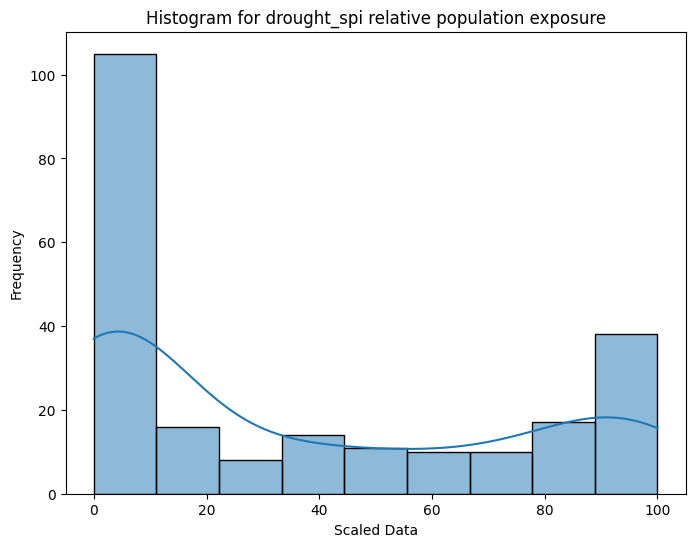

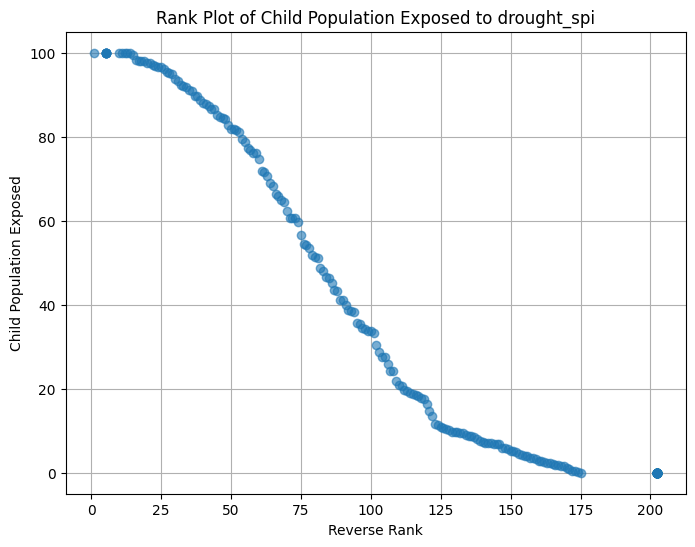

0.0
100.00000000000003
Processed: heatwave_frequency | Min: 0.9499324898673419 | Max: 100.0
heatwave_frequency: Log Transformation - skew=-0.662, kurtosis=-0.744
IQR processed : heatwave_frequency min: -3615680.4577229726 max: 6038760.87622179


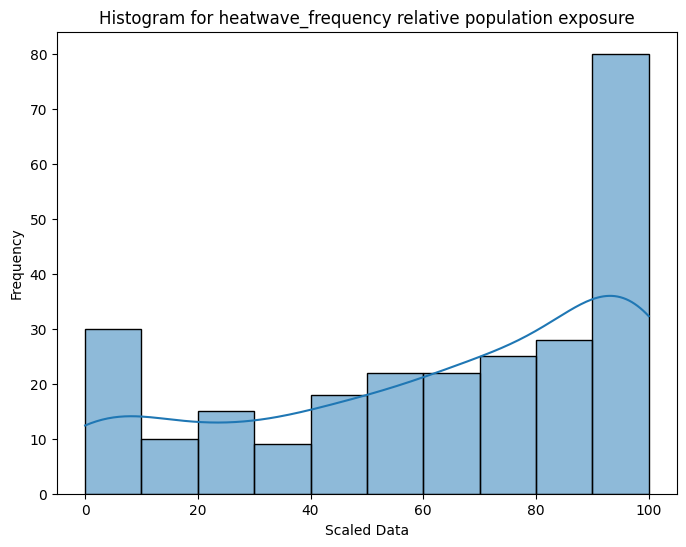

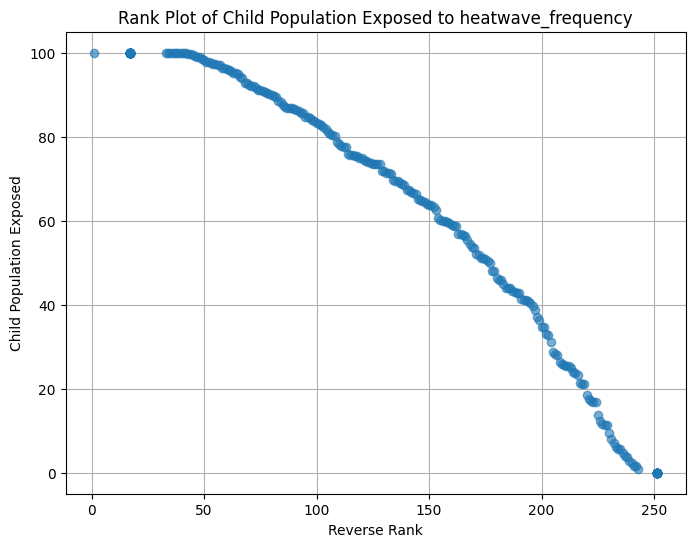

0.0
100.00000000000003
Processed: heatwave_duration | Min: 0.010957725033430264 | Max: 100.0
heatwave_duration: Log Transformation - skew=-0.130, kurtosis=-1.412
IQR processed : heatwave_duration min: -2990859.478031652 max: 4984765.79671942


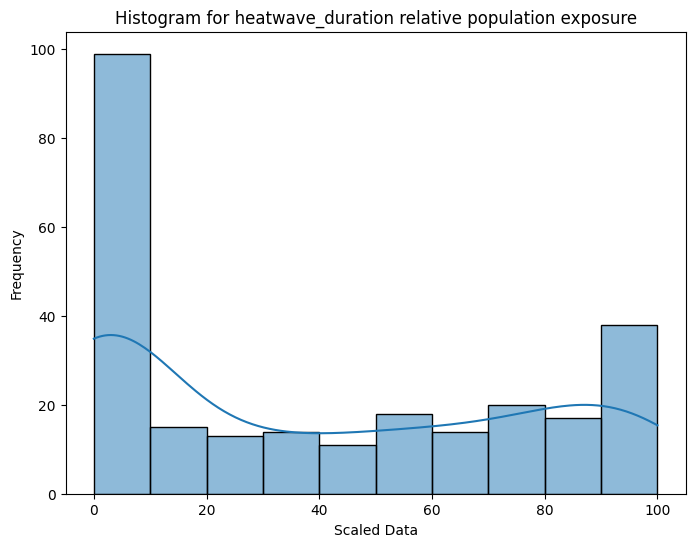

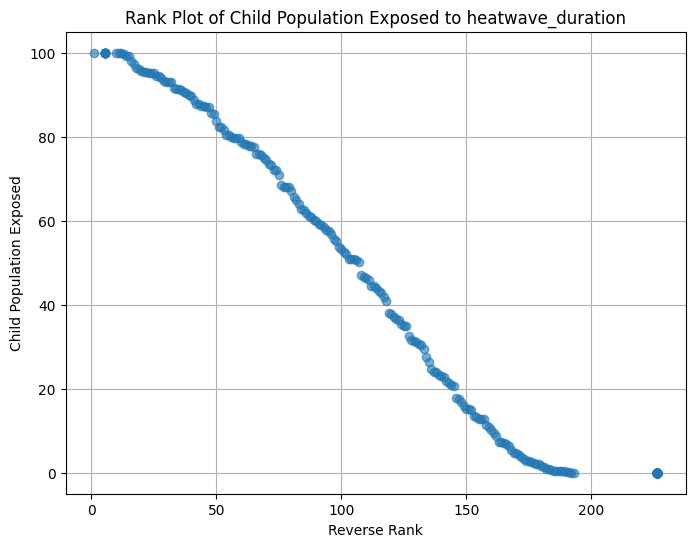

0.0
99.24831444902549
Processed: heatwave_severity | Min: 1.519718805056361e-06 | Max: 88.8481758200347
heatwave_severity: Log Transformation - skew=1.263, kurtosis=0.540
IQR processed : heatwave_severity min: -130113.71641504327 max: 216856.1940250721


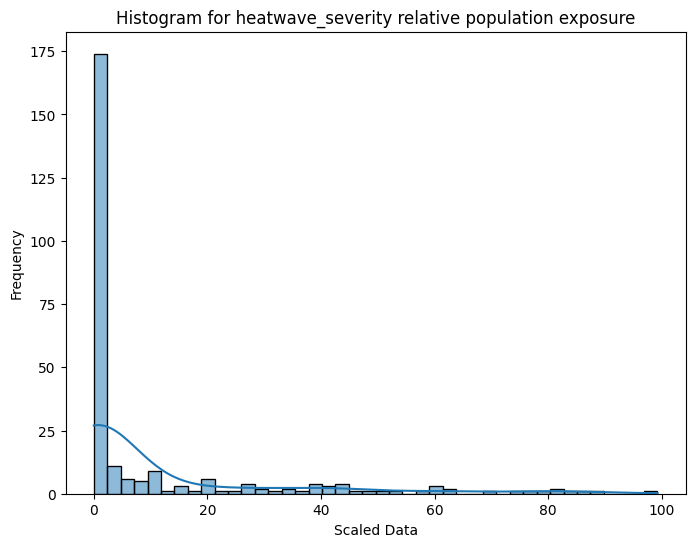

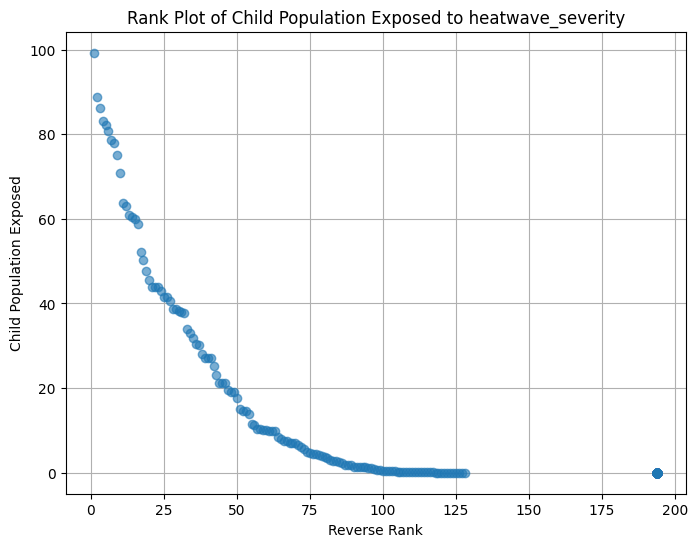

0.0
100.0
Processed: extreme_heat | Min: 0.00012540401317451567 | Max: 99.99999999999999
extreme_heat: Log Transformation - skew=0.329, kurtosis=-1.374
IQR processed : extreme_heat min: -2467172.5411543795 max: 4111954.235257299


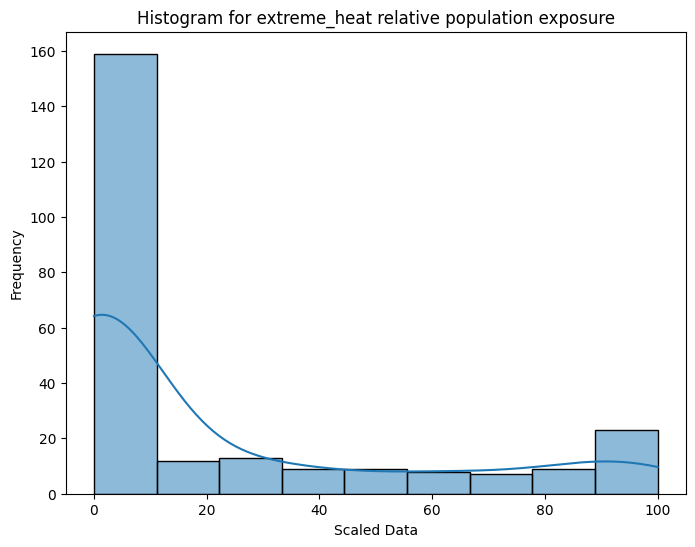

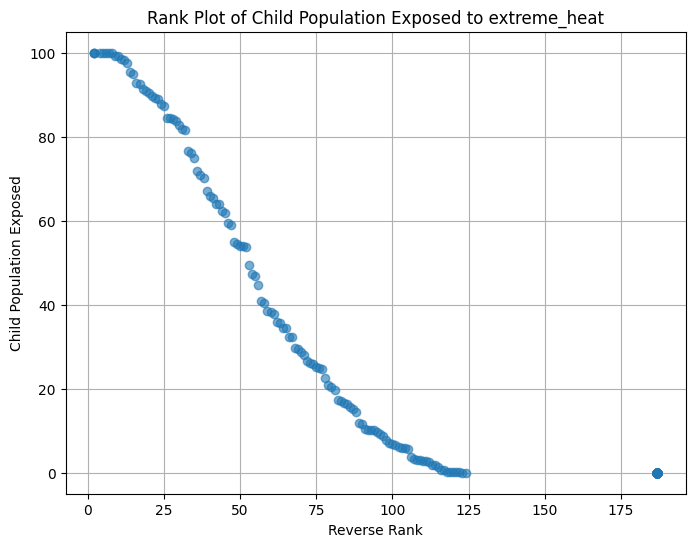

0.0
49.54498100687577
Processed: fire_FRP | Min: 0.17420590897752575 | Max: 22.03191784243058
fire_FRP: Log Transformation - skew=1.747, kurtosis=3.378
IQR processed : fire_FRP min: -404438.45285071403 max: 674581.0845105473


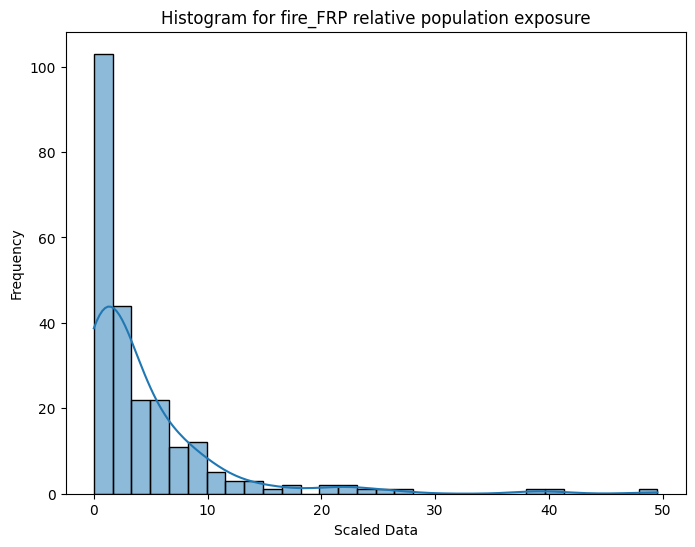

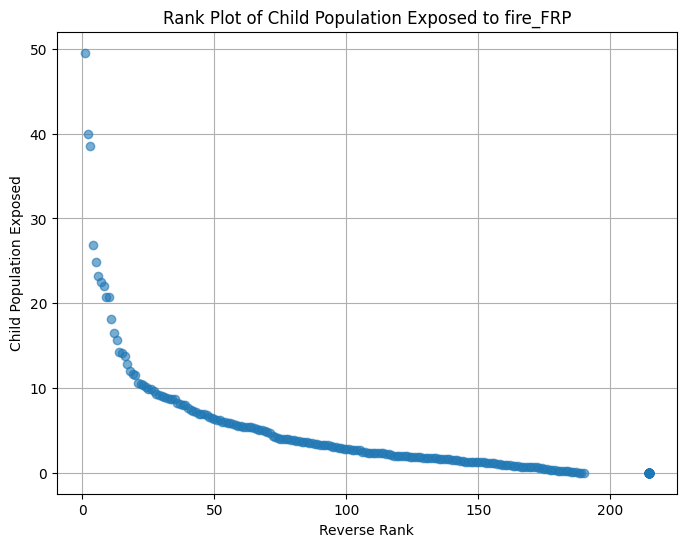

0.0
72.0188117789529
Processed: fire_frequency | Min: 0.08023264330895222 | Max: 27.602086859923137
fire_frequency: Log Transformation - skew=1.828, kurtosis=3.336
IQR processed : fire_frequency min: -334418.61828542786 max: 557364.658988609


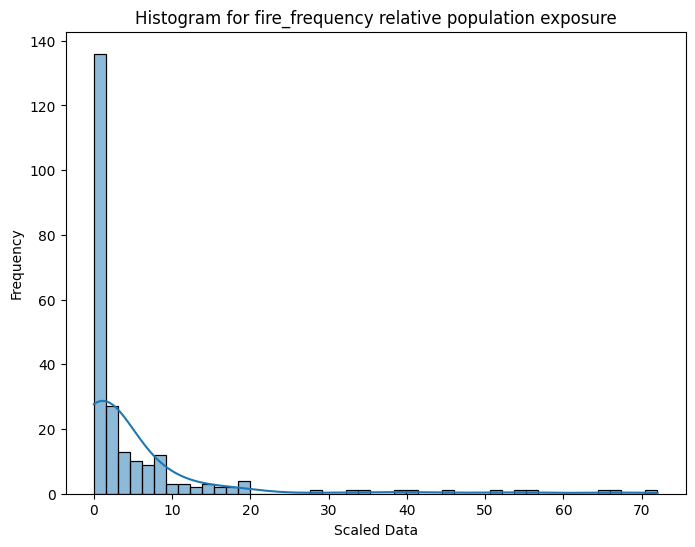

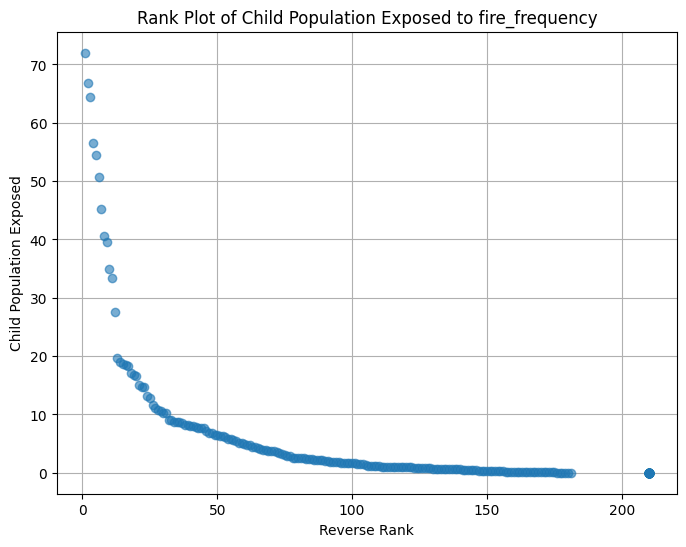

0.0
100.0
Processed: sand_dust | Min: 0.015528707555793891 | Max: 12.451761179508859
sand_dust: Log Transformation - skew=1.968, kurtosis=3.074
IQR processed : sand_dust min: -55260.34248024538 max: 92100.57080040897


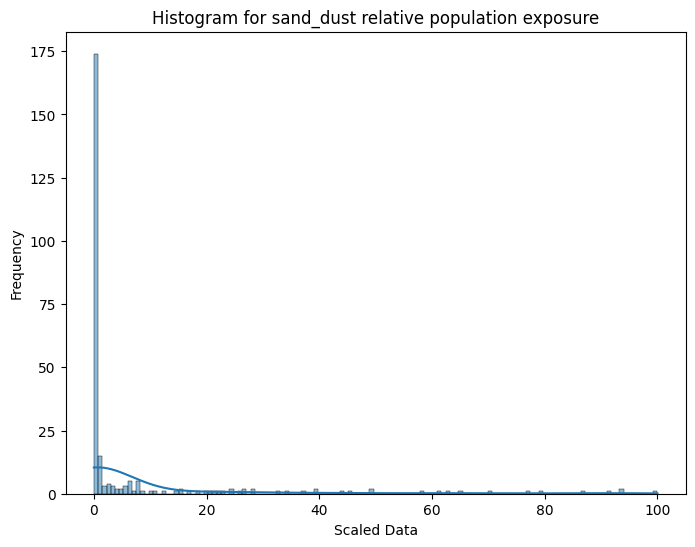

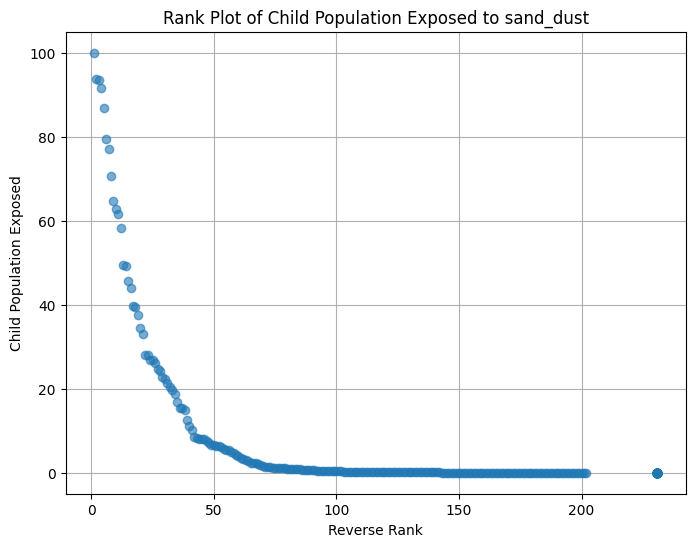

0.0
100.00000000000003
Processed: air_pollution | Min: 0.36520751486728076 | Max: 100.0
air_pollution: Log Transformation - skew=-1.751, kurtosis=2.079
IQR processed : air_pollution min: -9498337.46663632 max: 15860414.772642732


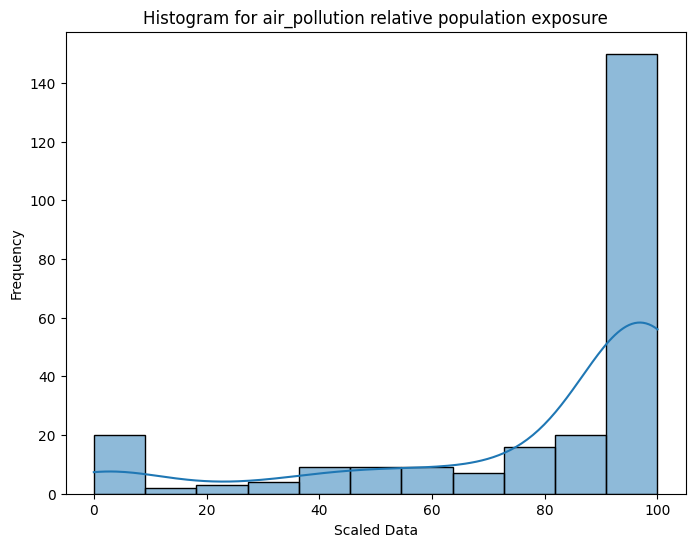

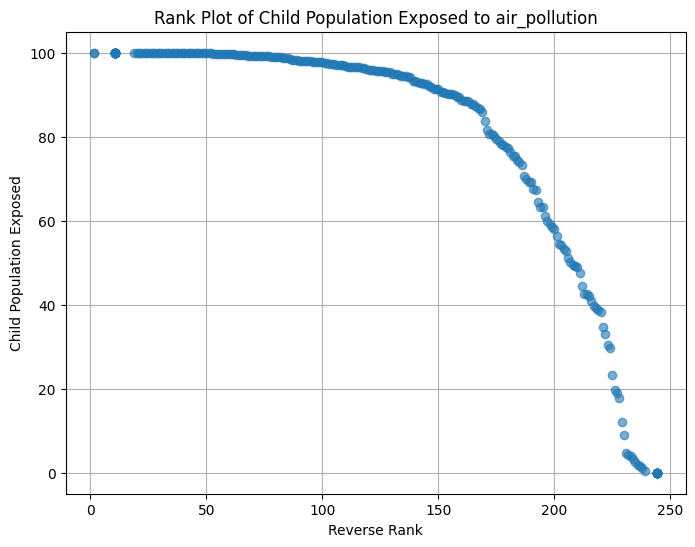

0.0
99.99443007103314
Processed: vectorborne_malariapv | Min: 0.00028292404050142203 | Max: 99.93654383047235
vectorborne_malariapv: Log Transformation - skew=0.721, kurtosis=-1.225
IQR processed : vectorborne_malariapv min: -1211626.3346359825 max: 2019377.2243933042


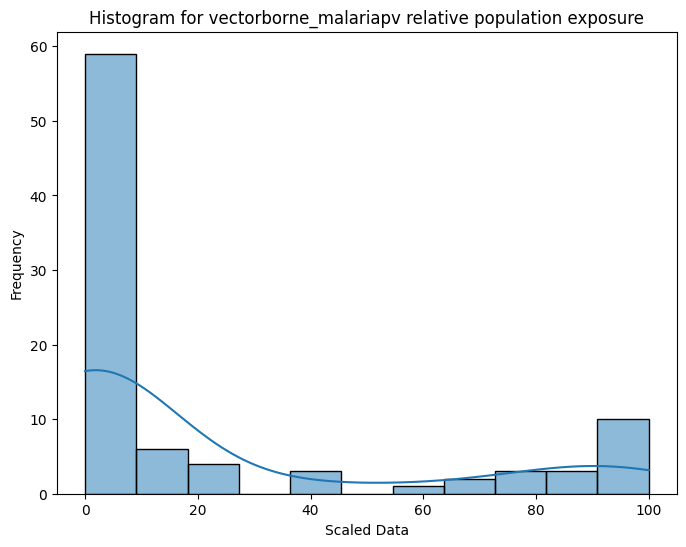

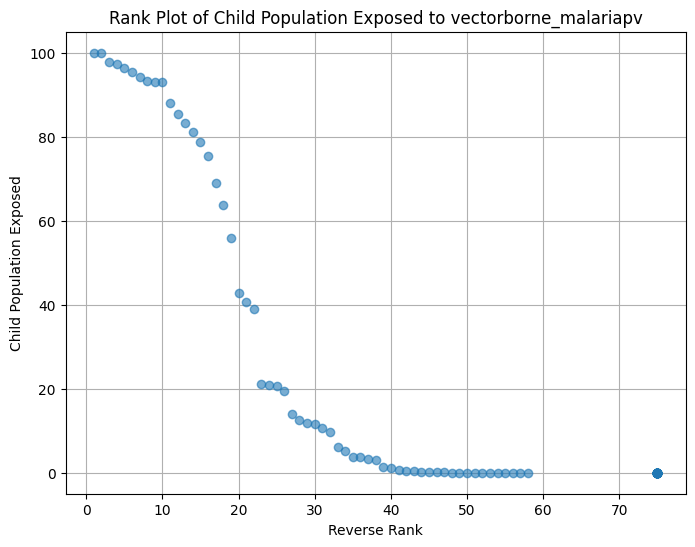

0.0
100.0
Processed: vectorborne_malariapf | Min: 0.00010586671378094335 | Max: 99.99999999999999
vectorborne_malariapf: Log Transformation - skew=-0.295, kurtosis=-1.718
IQR processed : vectorborne_malariapf min: -7834151.645395872 max: 13056919.408993121


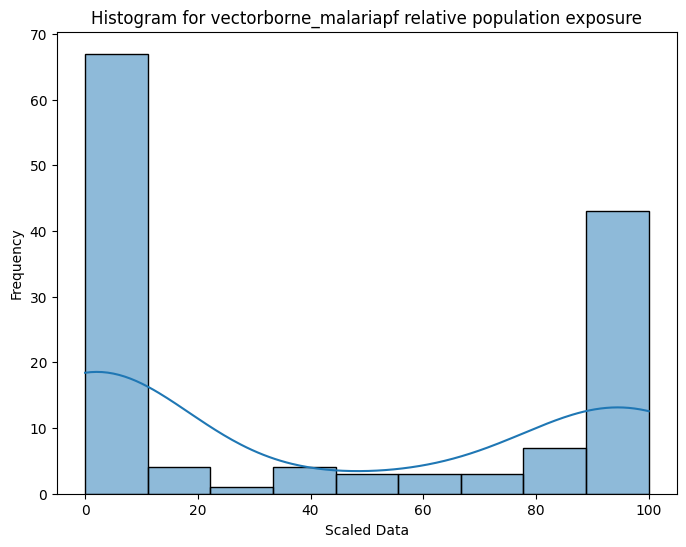

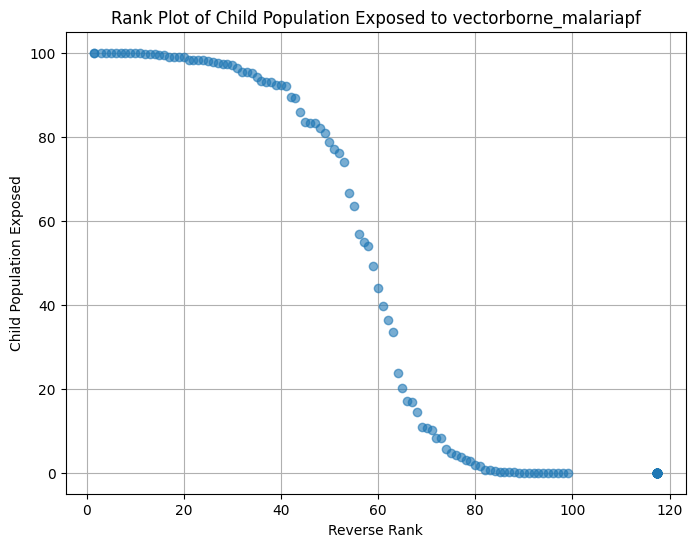

In [155]:

# Process each hazard file
for file in all_files:
    # Exclude the total population file
    df = pd.read_csv(file, index_col=None, header=0)
    df = df.rename(columns={'exposed': 'child_population_exposed'})
    df = df.rename(columns={'child_total': 'child_population_total'})
    filename_only = file.split('/')[-1]
    hazard_name = '_'.join(filename_only.split('_')[:2])

    if iso3_name not in df.columns or 'child_population_exposed' not in df.columns:
        continue  # Skip files missing required columns

    df = df[[ucode_name, iso3_name, 'child_population_exposed','child_population_total']].dropna()
    df['relative_population_exposure'] = np.where(
        (df['child_population_total'] > 0) & (~df['child_population_total'].isna()),
        (df['child_population_exposed'] / df['child_population_total']) * 100,
        np.nan  # Assign NaN instead of inf
    )

    print( df['relative_population_exposure'].min())
    print( df['relative_population_exposure'].max())
    # Apply iterative trimming
    # Trim outliers
    trimmed_values, min_trimmed, max_trimmed = trim_outliers_iteratively(df['relative_population_exposure'])
    iqr_trimmed_values, iqr_lower_bound, iqr_upper_bound = boxplot_outlier_detection(df['child_population_exposed'])
    # Check if there are enough values to calculate skewness and kurtosis
    if len(trimmed_values) > 2:
        current_skew = skew(trimmed_values)
        current_kurtosis = kurtosis(trimmed_values)
    else:
        current_skew, current_kurtosis = np.nan, np.nan

    print(f"Processed: {hazard_name} | Min: {min_trimmed} | Max: {max_trimmed}" )
    print(f"{hazard_name}: Log Transformation - skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")
    print(f"IQR processed : {hazard_name} min: {iqr_lower_bound} max: {iqr_upper_bound}" )

    # Plot histogram and normality check
    plt.figure(figsize=(8, 6))
    sns.histplot(df['relative_population_exposure'], kde=True)
    plt.title(f"Histogram for {hazard_name} relative population exposure")
    plt.xlabel("Scaled Data")
    plt.ylabel("Frequency")
    plt.show()


    # Compute ranks in reverse order
    df['rank_reverse'] = df['relative_population_exposure'].rank(method='average', ascending=False)
    plt.figure(figsize=(8, 6))
    plt.plot(df['rank_reverse'], df['relative_population_exposure'], marker='o', linestyle='', alpha=0.6)
    plt.xlabel("Reverse Rank")
    plt.ylabel("Child Population Exposed")
    plt.title(f"Rank Plot of Child Population Exposed to {hazard_name}")
    plt.grid(True)
    plt.show()




In [158]:
import os
import numpy as np
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew, kurtosis

# Define file paths
exposure_path = f'{data_dir}/pillar1_data'

# Get all CSV files for exposure
exposure_files = glob.glob(os.path.join(exposure_path, "*.csv"))

# Initialize empty list for processed data
exposure_data_list = []

# Files that should treat No Data as 0
ZERO_FILL_FILES = [
    "agricultural_drought_fao_1984-2023_exposure_adm0.csv",
    "tropical_storm_100yr_giri_2024_exposure_adm0.csv",
    "vectorborne_malariapf_2012-2022_exposure_adm0.csv",
    "vectorborne_malariapv_2012-2022_exposure_adm0.csv"
]

# --- Initialize the Master Dataframe ---
# Mapping the input adm0_df columns to your specified variable names

merged_exposure_df = merged_exposure_df[[iso3_name]]
merged_exposure_df = merged_exposure_df.drop_duplicates(subset=['iso3'], keep='first')

### **Process Each File in One Loop**
for file in exposure_files:

    df = pd.read_csv(file)  # Read full file to check available columns
    df = df[['iso3', 'child_population_exposed', 'child_population_total']]
    df = (df.groupby('iso3').sum(numeric_only=True, min_count=1).reset_index())

    #df =  df[df['type'] == 'State'] #filter out areas other than 'State' - now for all countries
    filename_only = os.path.basename(file)
    hazard_name = '_'.join(filename_only.split('_')[:2])  # Extract hazard name

    # Ensure required columns exist
    required_cols = {iso3_name, 'child_population_exposed', 'child_population_total'}
    if not required_cols.issubset(df.columns):
        print(f"Skipping {file}: Missing columns {required_cols - set(df.columns)}")
        continue  # Skip if required columns are missing

        # --- Special Handling for No Data ---
    if filename_only in ZERO_FILL_FILES:
        # Fill missing numeric values with 0 for specified hazards
        df['child_population_exposed'] = df.get('child_population_exposed', pd.Series(dtype=float)).fillna(0)
    else:
        # For other files, we drop rows where exposure is missing
        # (or handle as NaN which will naturally propagate)
        if 'child_population_exposed' in df.columns:
            df = df.dropna(subset=['child_population_exposed'])

    ### **Step 1: Absolute Exposure Processing**

    df['absolute_exposure'] = np.where(
    df['child_population_exposed'].isna(),
    np.nan,
    np.where(
        df['child_population_exposed'] > 100,
        np.log10(df['child_population_exposed'].clip(lower=1)),
        0.1
        )
    )
    #open min_max data file and use them to normalize the values
    df_min_max = pd.read_csv(f'{data_dir}/misc/p1_min_max.csv')
    min_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'abs'),'min'].values[0]
    max_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'abs'),'max'].values[0]

    # clip to min max
    valid = df['absolute_exposure'].notna()

    # Clip only valid values
    df.loc[valid, 'absolute_exposure'] = np.clip(
        df.loc[valid, 'absolute_exposure'],
        min_trimmed,
        max_trimmed
    )

    # Scale only valid values
    scaler = MinMaxScaler(feature_range=(1, 10))
    df.loc[valid, 'absolute_value_normalized'] = scaler.fit_transform(
        df.loc[valid, ['absolute_exposure']]
    ).flatten()

    ### **Step 2: Relative Exposure Processing**

    # Compute relative exposure (%)
    df['relative_exposure'] = np.where(
    df['child_population_exposed'].isna(),
    np.nan,
    np.where(
            (df['child_population_total'] > 0),
            (df['child_population_exposed'] / df['child_population_total']) * 100,
            0
        )
    )

    # #get min max values for relative exposures
    min_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'rel'),'min'].values[0]
    max_trimmed = df_min_max.loc[(df_min_max['filename'] == hazard_name) & (df_min_max['type'] == 'rel'),'max'].values[0]

    # # # Normalize relative exposure
    valid = df['relative_exposure'].notna()

    df.loc[valid, 'relative_exposure'] = np.clip(
        df.loc[valid, 'relative_exposure'],
        min_trimmed,
        max_trimmed
    )

    scaler = MinMaxScaler(feature_range=(1, 10))

    df.loc[valid, 'relative_value_normalized'] = scaler.fit_transform(
        df.loc[valid, ['relative_exposure']]
    ).flatten()

    # Rename columns for final merging
    df.rename(columns={
        'absolute_value_normalized': hazard_name + '_absolute',
        'relative_value_normalized': hazard_name + '_relative'
    }, inplace=True)

    hazard_df = df[[iso3_name, hazard_name + '_absolute', hazard_name + '_relative']]
    merged_exposure_df = merged_exposure_df.merge(hazard_df, on='iso3', how='left')





In [159]:

# Save merged exposure data
output_path = f"{data_dir}/misc/Merged_Exposure_Data.csv"
merged_exposure_df.to_csv(output_path, index=False)
print(f"Merged exposure data saved to {output_path}")

Merged exposure data saved to /content/drive/MyDrive/CCRI/CCRR_repo/data/misc/Merged_Exposure_Data.csv
